In [7]:
# ============================================================
# =============== CELL A — USER INPUTS ONLY ==================
# ============================================================

# ---- Camera folder (raw .raw frames) ----
CAM_FOLDER = r"D:\Kevin\04032026\04032026-1\cam1"

# ---- NI-DAQ TTL folder ----
NI_TTL_FOLDER = r"G:\Kevin\2026-03-04_08-31-33\Record Node 104\experiment1\recording1\events\NI-DAQmx-103.PXIe-6341\TTL"

# ---- Regex pattern for camera filenames ----
# Example: frame_030293_cnt_1575696.raw
FILENAME_PATTERN = r"frame_(\d+)_cnt_(\d+)\.raw"

# ---- Path to DLC output (.h5 or .csv) ----
DLC_OUTPUT_PATH = r"F:\Mouse1_030426-Kpk\videos\04032026-1_cam1DLC_Resnet50_Mouse1_030426Apr23shuffle2_snapshot_best-100.h5"

# ---- TTL pin (0 or 7 depending on wiring) ----
TTL_PIN = 0

print("User inputs loaded successfully.")

User inputs loaded successfully.


In [8]:
# ============================================================
# ========== CELL B — TTL ↔ FRAME ALIGNMENT MODULE ===========
# ============================================================

import os
import re
import numpy as np

print("\n===== TTL ↔ Frame Alignment Module =====")

# ------------------------------------------------------------
# 1. Compile filename regex
# ------------------------------------------------------------
PATTERN = re.compile(FILENAME_PATTERN)

# ------------------------------------------------------------
# 2. Load NI-DAQ TTL data
# ------------------------------------------------------------
timestamps_ni = np.load(os.path.join(NI_TTL_FOLDER, "timestamps.npy"))
states_ni     = np.load(os.path.join(NI_TTL_FOLDER, "states.npy"))
full_words_ni = np.load(os.path.join(NI_TTL_FOLDER, "full_words.npy"))

print("Loaded NI-DAQ TTL data.")

# Extract rising edges for camera pulses
bit_mask = 1 << TTL_PIN
ttl_signal = (full_words_ni & bit_mask) > 0
ttl_diff = np.diff(ttl_signal.astype(int))
rising_edges = np.where(ttl_diff == 1)[0] + 1

ttl_times = timestamps_ni[rising_edges]
TTL_COUNT = len(ttl_times)

print(f"Detected {TTL_COUNT} TTL pulses.")

# ------------------------------------------------------------
# 3. Load camera frame filenames
# ------------------------------------------------------------
entries = []

for fname in os.listdir(CAM_FOLDER):
    m = PATTERN.match(fname)
    if m:
        frame_idx = int(m.group(1))
        counter   = int(m.group(2))
        entries.append((frame_idx, counter, fname))

if not entries:
    raise RuntimeError("No valid frame files found in CAM_FOLDER.")

# Sort by chunk counter (camera truth)
entries.sort(key=lambda x: x[1])

frame_indices = np.array([e[0] for e in entries])
counters      = np.array([e[1] for e in entries])
filenames     = [e[2] for e in entries]

print(f"Loaded {len(entries)} camera frames.")

# ------------------------------------------------------------
# 4. Integrity check (frame index + chunk counter)
# ------------------------------------------------------------
print("\n===== FRAME INTEGRITY CHECK =====")

missing_frame_idx_total = 0
missing_counter_total   = 0
problems = []

last_frame = None
last_counter = None

for frame_idx, counter, fname in entries:
    if last_frame is not None:
        # Frame index continuity
        expected_frame = last_frame + 1
        if frame_idx != expected_frame:
            gap = frame_idx - expected_frame
            missing_frame_idx_total += gap
            problems.append(
                f"FRAME INDEX GAP: {last_frame} → {frame_idx} (missing {gap})"
            )

        # Chunk counter continuity
        expected_counter = last_counter + 1
        if counter != expected_counter:
            gap = counter - expected_counter
            missing_counter_total += gap
            problems.append(
                f"CHUNK COUNTER GAP: {last_counter} → {counter} "
                f"(missing {gap}) at frame {frame_idx} ({fname})"
            )

    last_frame = frame_idx
    last_counter = counter

print(f"Total saved frames: {len(entries)}")
print(f"Missing by frame index: {missing_frame_idx_total}")
print(f"Missing by chunk counter (ground truth): {missing_counter_total}")

if problems:
    print("\n⚠️  PROBLEMS DETECTED:")
    for p in problems:
        print(" -", p)
else:
    print("\n✅ No discrepancies detected.")

# ------------------------------------------------------------
# 5. Build TTL-aligned frame timeline
# ------------------------------------------------------------
print("\n===== BUILDING TTL-ALIGNED TIMELINE =====")

aligned_frames = [None] * TTL_COUNT

counter_to_file = {c: f for (_, c, f) in entries}
first_counter = counters[0]

for ttl_idx in range(TTL_COUNT):
    counter_value = first_counter + ttl_idx
    aligned_frames[ttl_idx] = counter_to_file.get(counter_value, None)

missing = sum(f is None for f in aligned_frames)

# Save output
out_path = os.path.join(CAM_FOLDER, "aligned_frames.npy")
np.save(out_path, aligned_frames)

print(f"Saved aligned_frames.npy → {out_path}")
print(f"Missing frames inserted: {missing}")

print("\n===== MODULE COMPLETE =====\n")


===== TTL ↔ Frame Alignment Module =====
Loaded NI-DAQ TTL data.
Detected 134516 TTL pulses.
Loaded 120268 camera frames.

===== FRAME INTEGRITY CHECK =====
Total saved frames: 120268
Missing by frame index: 0
Missing by chunk counter (ground truth): 13648

⚠️  PROBLEMS DETECTED:
 - CHUNK COUNTER GAP: 1572529 → 1573024 (missing 494) at frame 27621 (frame_027621_cnt_1573024.raw)
 - CHUNK COUNTER GAP: 1575696 → 1576093 (missing 396) at frame 30294 (frame_030294_cnt_1576093.raw)
 - CHUNK COUNTER GAP: 1579116 → 1579588 (missing 471) at frame 33318 (frame_033318_cnt_1579588.raw)
 - CHUNK COUNTER GAP: 1582620 → 1583083 (missing 462) at frame 36351 (frame_036351_cnt_1583083.raw)
 - CHUNK COUNTER GAP: 1586036 → 1586519 (missing 482) at frame 39305 (frame_039305_cnt_1586519.raw)
 - CHUNK COUNTER GAP: 1591201 → 1591669 (missing 467) at frame 43988 (frame_043988_cnt_1591669.raw)
 - CHUNK COUNTER GAP: 1594413 → 1594888 (missing 474) at frame 46733 (frame_046733_cnt_1594888.raw)
 - CHUNK COUNTER G


===== Timeline Visualization Module =====
TTL pulses detected: 134516
Loaded aligned_frames.npy successfully.

===== DURATIONS =====
NI-DAQ duration:     2446.51 s
TTL active duration: 2243.03 s
Frame timeline:      2243.03 s


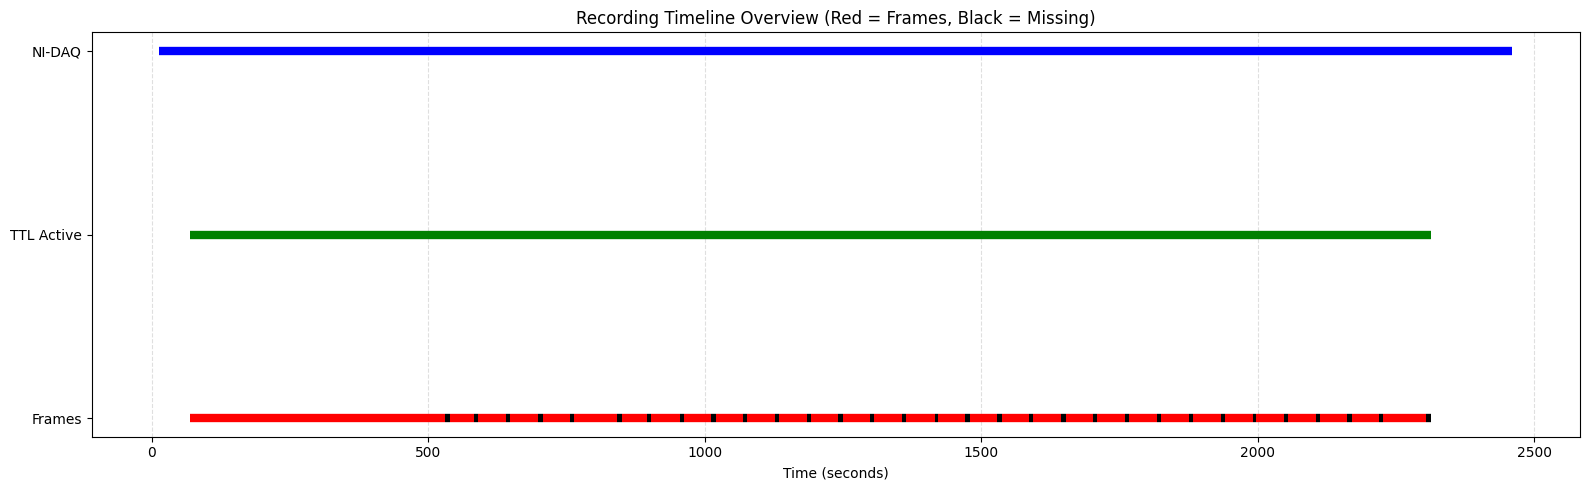


===== MODULE COMPLETE =====



In [9]:
# ============================================================
# ========== CELL C — TIMELINE VISUALIZATION MODULE ==========
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

print("\n===== Timeline Visualization Module =====")

# ------------------------------------------------------------
# 1. Load NI-DAQ TTL data
# ------------------------------------------------------------
timestamps_ni = np.load(os.path.join(NI_TTL_FOLDER, "timestamps.npy"))
full_words_ni = np.load(os.path.join(NI_TTL_FOLDER, "full_words.npy"))

bit_mask = 1 << TTL_PIN
ttl_signal = (full_words_ni & bit_mask) > 0
ttl_diff = np.diff(ttl_signal.astype(int))
rising_edges = np.where(ttl_diff == 1)[0] + 1

ttl_times = timestamps_ni[rising_edges]
TTL_COUNT = len(ttl_times)

print(f"TTL pulses detected: {TTL_COUNT}")

# ------------------------------------------------------------
# 2. Load aligned_frames.npy
# ------------------------------------------------------------
aligned_frames_path = os.path.join(CAM_FOLDER, "aligned_frames.npy")
aligned_frames = np.load(aligned_frames_path, allow_pickle=True)

assert len(aligned_frames) == TTL_COUNT, (
    f"Mismatch: TTL_COUNT={TTL_COUNT} but aligned_frames={len(aligned_frames)}"
)

print("Loaded aligned_frames.npy successfully.")

# ------------------------------------------------------------
# 3. Compute durations
# ------------------------------------------------------------
ni_start = timestamps_ni[0]
ni_end   = timestamps_ni[-1]
ni_duration = ni_end - ni_start

ttl_start = ttl_times[0]
ttl_end   = ttl_times[-1]
ttl_duration = ttl_end - ttl_start

print("\n===== DURATIONS =====")
print(f"NI-DAQ duration:     {ni_duration:.2f} s")
print(f"TTL active duration: {ttl_duration:.2f} s")
print(f"Frame timeline:      {ttl_duration:.2f} s")

# ------------------------------------------------------------
# 4. Visualization
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 5))

# Row positions
y_ni = 3
y_ttl = 2
y_frames = 1

# --- NI-DAQ full recording ---
ax.hlines(y_ni, ni_start, ni_end, color='blue', linewidth=6, label="NI-DAQ Recording")

# --- TTL active window ---
ax.hlines(y_ttl, ttl_start, ttl_end, color='green', linewidth=6, label="Camera TTL Active")

# --- Frame timeline (red = present, black = missing) ---
for i, f in enumerate(aligned_frames):
    t0 = ttl_times[i]
    if i < TTL_COUNT - 1:
        t1 = ttl_times[i+1]
    else:
        t1 = t0 + (ttl_times[-1] - ttl_times[-2])  # last interval same width as previous

    color = 'red' if f is not None else 'black'
    ax.hlines(y_frames, t0, t1, color=color, linewidth=6)

ax.set_yticks([y_ni, y_ttl, y_frames])
ax.set_yticklabels(["NI-DAQ", "TTL Active", "Frames"])

ax.set_xlabel("Time (seconds)")
ax.set_title("Recording Timeline Overview (Red = Frames, Black = Missing)")
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\n===== MODULE COMPLETE =====\n")

In [10]:
# ============================================================
# ========== CELL D — DLC ↔ TTL ALIGNMENT MODULE =============
# ============================================================

import os
import numpy as np
import pandas as pd

print("\n===== DLC ↔ TTL Alignment Module =====")

# ------------------------------------------------------------
# 1. Load aligned_frames.npy
# ------------------------------------------------------------
aligned_frames_path = os.path.join(CAM_FOLDER, "aligned_frames.npy")
aligned_frames = np.load(aligned_frames_path, allow_pickle=True)
TTL_COUNT = len(aligned_frames)

print(f"Loaded aligned_frames.npy with {TTL_COUNT} TTL entries.")

# ------------------------------------------------------------
# 2. Load DLC output
# ------------------------------------------------------------
if DLC_OUTPUT_PATH.endswith(".csv"):
    df_dlc = pd.read_csv(DLC_OUTPUT_PATH)
elif DLC_OUTPUT_PATH.endswith(".h5") or DLC_OUTPUT_PATH.endswith(".hdf5"):
    df_dlc = pd.read_hdf(DLC_OUTPUT_PATH)
else:
    raise ValueError("DLC output must be .csv or .h5")

DLC_FRAME_COUNT = len(df_dlc)
print(f"Loaded DLC output with {DLC_FRAME_COUNT} rows.")

# ------------------------------------------------------------
# 3. Build mapping: DLC row index → DLC row
# ------------------------------------------------------------
# IMPORTANT:
# DLC row i corresponds to the i-th PRESENT frame in the video,
# NOT the raw frame index, because missing frames were removed
# when the video was encoded.

dlc_by_row = {i: df_dlc.iloc[i] for i in range(DLC_FRAME_COUNT)}

# ------------------------------------------------------------
# 4. Build TTL-aligned DLC timeline
# ------------------------------------------------------------
dlc_aligned = []

# We need a list of raw frame indices for present frames
# in the order DLC saw them.
present_raw_indices = [
    int(f.split("_")[1])
    for f in aligned_frames
    if f is not None
]

# But DLC rows correspond to the *order* of present frames,
# not the raw frame numbers.
# So DLC row 0 = first present frame
# DLC row 1 = second present frame
# etc.

# Build mapping: raw_frame_index → DLC row index
raw_to_dlc_row = {
    raw_idx: i
    for i, raw_idx in enumerate(present_raw_indices)
    if i < DLC_FRAME_COUNT
}

# Now build dlc_aligned
for f in aligned_frames:
    if f is None:
        dlc_aligned.append(None)
    else:
        raw_idx = int(f.split("_")[1])
        dlc_row = raw_to_dlc_row.get(raw_idx, None)
        if dlc_row is None:
            dlc_aligned.append(None)
        else:
            dlc_aligned.append(dlc_by_row[dlc_row])

dlc_aligned = np.array(dlc_aligned, dtype=object)

print("Built dlc_aligned timeline.")
print(f"Length: {len(dlc_aligned)}")
print(f"Missing DLC entries: {sum(x is None for x in dlc_aligned)}")

# ------------------------------------------------------------
# 5. Save output
# ------------------------------------------------------------
output_path = os.path.join(CAM_FOLDER, "dlc_aligned.npy")
np.save(output_path, dlc_aligned)

print(f"\nSaved dlc_aligned.npy to:\n{output_path}")
print("\n===== MODULE COMPLETE =====\n")


===== DLC ↔ TTL Alignment Module =====
Loaded aligned_frames.npy with 134516 TTL entries.
Loaded DLC output with 120268 rows.
Built dlc_aligned timeline.
Length: 134516
Missing DLC entries: 14248

Saved dlc_aligned.npy to:
D:\Kevin\04032026\04032026-1\cam1\dlc_aligned.npy

===== MODULE COMPLETE =====




===== DLC Trajectory Plotting Module =====
Loaded dlc_aligned timeline with 134516 entries.


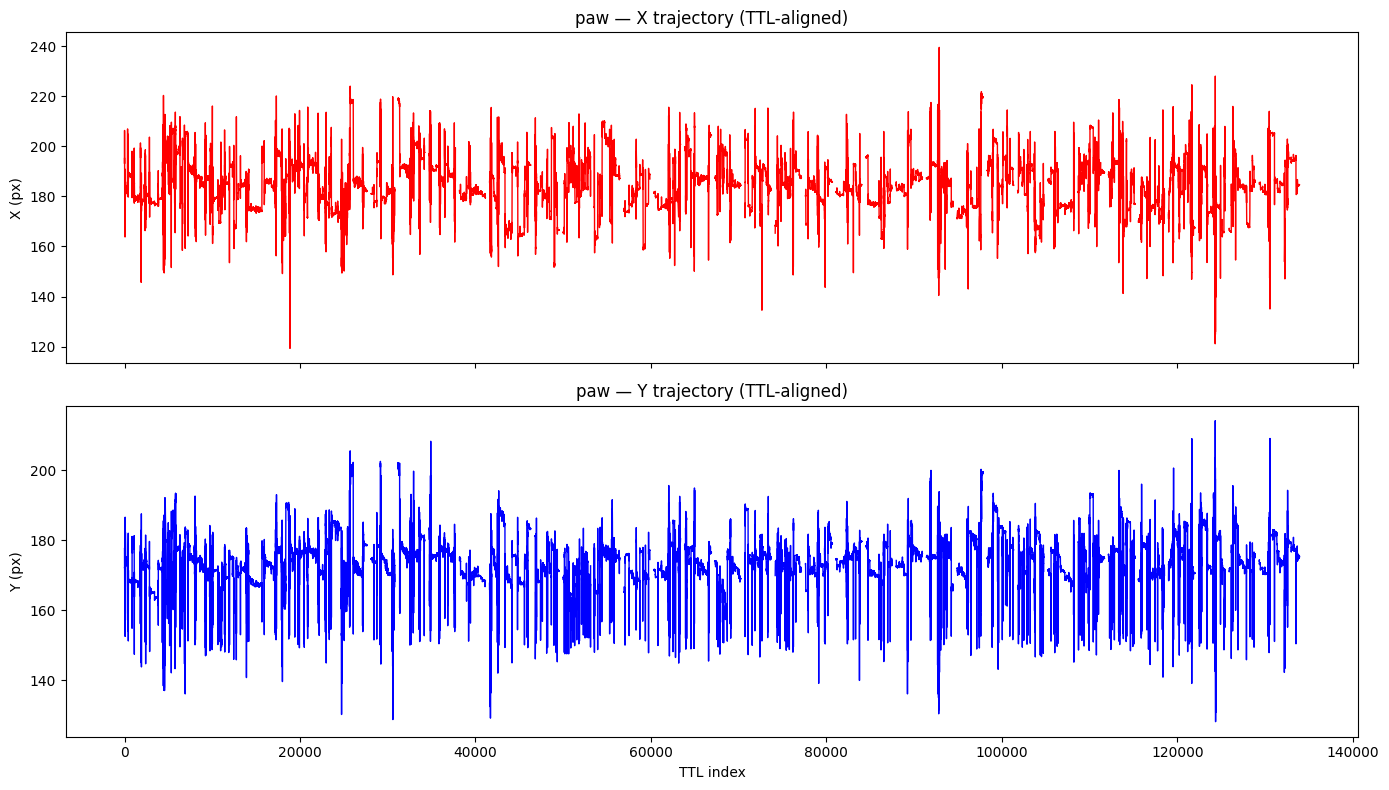


===== MODULE COMPLETE =====



In [11]:
# ============================================================
# ========== CELL E — DLC TRAJECTORY PLOTTING MODULE =========
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n===== DLC Trajectory Plotting Module =====")

# ------------------------------------------------------------
# 1. Load dlc_aligned.npy
# ------------------------------------------------------------
dlc_aligned_path = os.path.join(CAM_FOLDER, "dlc_aligned.npy")
dlc_aligned = np.load(dlc_aligned_path, allow_pickle=True)

print(f"Loaded dlc_aligned timeline with {len(dlc_aligned)} entries.")

# ------------------------------------------------------------
# 2. Load DLC dataframe to inspect column structure
# ------------------------------------------------------------
df_dlc = pd.read_hdf(DLC_OUTPUT_PATH)

# Choose bodypart
bodypart = "paw"   ##############################################################################################################################################################

# Extract columns
cols = [c for c in df_dlc.columns if c[1] == bodypart]
x_col = [c for c in cols if c[2] == "x"][0]
y_col = [c for c in cols if c[2] == "y"][0]
lik_col = [c for c in cols if c[2] == "likelihood"][0]

# ------------------------------------------------------------
# 3. Build aligned trajectories
# ------------------------------------------------------------
x_aligned = []
y_aligned = []
lik_aligned = []

for row in dlc_aligned:
    if row is None:
        x_aligned.append(np.nan)
        y_aligned.append(np.nan)
        lik_aligned.append(np.nan)
    else:
        x_aligned.append(row[x_col])
        y_aligned.append(row[y_col])
        lik_aligned.append(row[lik_col])

x_aligned = np.array(x_aligned, dtype=float)
y_aligned = np.array(y_aligned, dtype=float)
lik_aligned = np.array(lik_aligned, dtype=float)

# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(x_aligned, color='red', linewidth=1)
ax[0].set_ylabel("X (px)")
ax[0].set_title(f"{bodypart} — X trajectory (TTL-aligned)")

ax[1].plot(y_aligned, color='blue', linewidth=1)
ax[1].set_ylabel("Y (px)")
ax[1].set_xlabel("TTL index")
ax[1].set_title(f"{bodypart} — Y trajectory (TTL-aligned)")

plt.tight_layout()
plt.show()

print("\n===== MODULE COMPLETE =====\n")

In [12]:
# ============================================================
# ========== CELL F — SANITY CHECK MODULE ====================
# ============================================================

import os
import numpy as np

print("\n===== Sanity Check Module =====")

aligned_frames = np.load(os.path.join(CAM_FOLDER, "aligned_frames.npy"), allow_pickle=True)
dlc_aligned    = np.load(os.path.join(CAM_FOLDER, "dlc_aligned.npy"), allow_pickle=True)

TTL_COUNT = len(aligned_frames)

print(f"TTL count: {TTL_COUNT}")
print(f"DLC-aligned length: {len(dlc_aligned)}")

# ------------------------------------------------------------
# 1. Check that every present frame has a DLC entry
# ------------------------------------------------------------
present_frames = sum(f is not None for f in aligned_frames)
present_dlc    = sum(x is not None for x in dlc_aligned)

print(f"Present frames: {present_frames}")
print(f"Present DLC entries: {present_dlc}")

if present_frames != present_dlc:
    print("⚠️ Mismatch detected: DLC entries do not match present frames.")
else:
    print("✅ DLC entries match present frames exactly.")

# ------------------------------------------------------------
# 2. Check for any DLC values outside expected range
# ------------------------------------------------------------
y_vals = np.array([
    row[y_col] if row is not None else np.nan
    for row in dlc_aligned
])

print(f"Max Y in DLC-aligned: {np.nanmax(y_vals)}")
print(f"Min Y in DLC-aligned: {np.nanmin(y_vals)}")

print("\n===== MODULE COMPLETE =====\n")


===== Sanity Check Module =====
TTL count: 134516
DLC-aligned length: 134516
Present frames: 120268
Present DLC entries: 120268
✅ DLC entries match present frames exactly.
Max Y in DLC-aligned: 214.2211456298828
Min Y in DLC-aligned: 128.0848388671875

===== MODULE COMPLETE =====




===== Peak Detection Module =====
Using threshold = 190, min_peak_distance = 50
Detected 70 peaks above threshold.

===== PEAK RESULTS =====
TTL   4611 | Frame   4611 | Y = 192.20
TTL   5821 | Frame   5821 | Y = 193.44
TTL   8040 | Frame   8040 | Y = 192.64
TTL  17321 | Frame  17321 | Y = 193.05
TTL  18415 | Frame  18415 | Y = 190.62
TTL  18465 | Frame  18465 | Y = 190.09
TTL  18516 | Frame  18516 | Y = 190.60
TTL  18607 | Frame  18607 | Y = 190.43
TTL  18705 | Frame  18705 | Y = 190.83
TTL  18762 | Frame  18762 | Y = 190.16
TTL  25644 | Frame  25644 | Y = 194.32
TTL  25718 | Frame  25718 | Y = 205.58
TTL  25780 | Frame  25780 | Y = 200.02
TTL  25830 | Frame  25830 | Y = 201.65
TTL  25898 | Frame  25898 | Y = 200.09
TTL  25985 | Frame  25985 | Y = 201.76
TTL  26060 | Frame  26060 | Y = 202.30
TTL  29164 | Frame  28670 | Y = 202.57
TTL  29233 | Frame  28739 | Y = 198.50
TTL  31205 | Frame  30315 | Y = 202.22
TTL  31258 | Frame  30368 | Y = 201.72
TTL  31354 | Frame  30464 | Y = 202.07


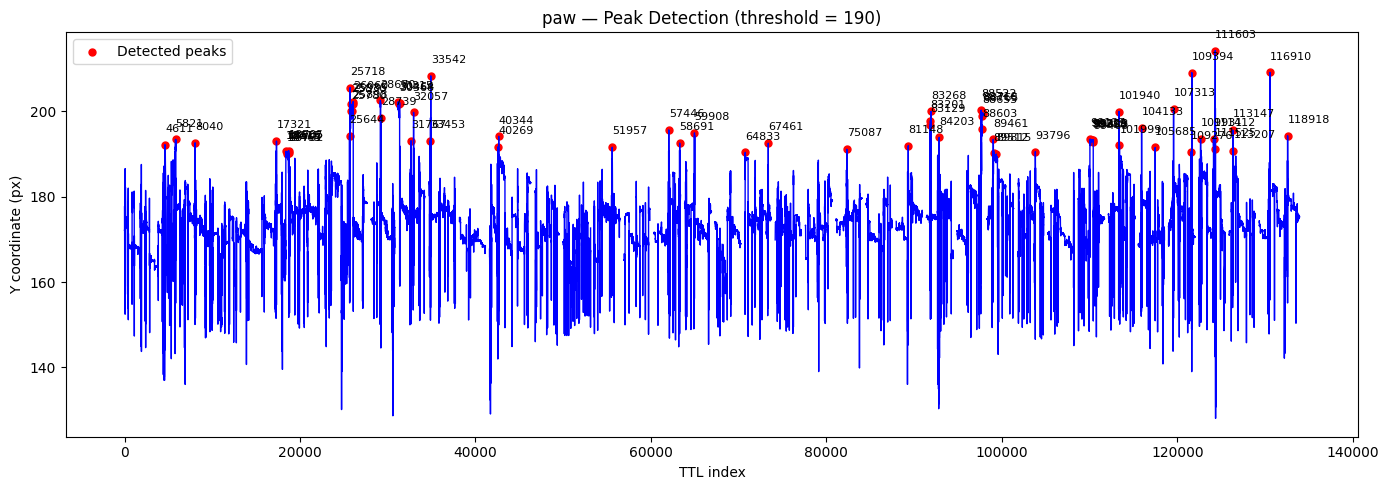


===== MODULE COMPLETE =====



In [13]:
# ============================================================
# ========== CELL G — PEAK DETECTION MODULE ==================
# ============================================================

import os
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

print("\n===== Peak Detection Module =====")

# ------------------------------------------------------------
# 1. Load aligned DLC trajectories (from Cell E)
# ------------------------------------------------------------
dlc_aligned_path = os.path.join(CAM_FOLDER, "dlc_aligned.npy")
dlc_aligned = np.load(dlc_aligned_path, allow_pickle=True)

# Load aligned_frames (from Cell B)
aligned_frames_path = os.path.join(CAM_FOLDER, "aligned_frames.npy")
aligned_frames = np.load(aligned_frames_path, allow_pickle=True)

TTL_COUNT = len(aligned_frames)
assert len(dlc_aligned) == TTL_COUNT, "Mismatch: dlc_aligned and aligned_frames lengths differ."

# ------------------------------------------------------------
# 2. Load DLC dataframe to get column structure
# ------------------------------------------------------------
df_dlc = pd.read_hdf(DLC_OUTPUT_PATH)

bodypart = "paw"   # You can change this if needed ##################################################################################################################################################

cols = [c for c in df_dlc.columns if c[1] == bodypart]
x_col   = [c for c in cols if c[2] == "x"][0]
y_col   = [c for c in cols if c[2] == "y"][0]
lik_col = [c for c in cols if c[2] == "likelihood"][0]

# ------------------------------------------------------------
# 3. Build aligned trajectories
# ------------------------------------------------------------
x_aligned = []
y_aligned = []
lik_aligned = []

for row in dlc_aligned:
    if row is None:
        x_aligned.append(np.nan)
        y_aligned.append(np.nan)
        lik_aligned.append(np.nan)
    else:
        x_aligned.append(row[x_col])
        y_aligned.append(row[y_col])
        lik_aligned.append(row[lik_col])

x_aligned = np.array(x_aligned, dtype=float)
y_aligned = np.array(y_aligned, dtype=float)
lik_aligned = np.array(lik_aligned, dtype=float)

# ------------------------------------------------------------
# 4. Peak detection settings
# ------------------------------------------------------------
threshold = 190          # Y-value threshold for a peak   ############################################################################################################################################
min_peak_distance = 50   # Minimum TTL indices between peaks #########################################################################################################################################

print(f"Using threshold = {threshold}, min_peak_distance = {min_peak_distance}")

# ------------------------------------------------------------
# 5. Detect peaks
# ------------------------------------------------------------
peaks, props = find_peaks(
    y_aligned,
    height=threshold,
    distance=min_peak_distance
)

print(f"Detected {len(peaks)} peaks above threshold.")

# ------------------------------------------------------------
# 6. Build results list (TTL index, raw frame index, Y value)
# ------------------------------------------------------------
results = []

for ttl_idx in peaks:
    fname = aligned_frames[ttl_idx]
    if fname is None:
        raw_idx = None
    else:
        raw_idx = int(fname.split("_")[1])

    peak_y = y_aligned[ttl_idx]
    results.append((ttl_idx, raw_idx, peak_y))

# Print results
print("\n===== PEAK RESULTS =====")
for ttl_idx, raw_idx, peak_y in results:
    print(f"TTL {ttl_idx:6d} | Frame {raw_idx:6d} | Y = {peak_y:.2f}")

# ------------------------------------------------------------
# 7. Plot with peak annotations
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_aligned, color='blue', linewidth=1)
ax.scatter(peaks, y_aligned[peaks], color='red', s=25, label="Detected peaks")

# Annotate with raw frame numbers
for ttl_idx, raw_idx, peak_y in results:
    if raw_idx is not None:
        ax.text(ttl_idx, peak_y + 3, str(raw_idx), fontsize=8, color='black')

ax.set_title(f"{bodypart} — Peak Detection (threshold = {threshold})")
ax.set_xlabel("TTL index")
ax.set_ylabel("Y coordinate (px)")
ax.legend()

plt.tight_layout()
plt.show()

print("\n===== MODULE COMPLETE =====\n")